# 03 — Model Training & Validation

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from pathlib import Path
import random

# using feature selector and modeling from two .py files
from src.features import build_team_features, build_matchup_df
from src.model import LogisticBaseline, MarchMadnessNet, evaluate

PROC_DIR = Path('../data/processed')
OUT_DIR  = Path('../outputs')

## 1. Rebuild Features

In [2]:
# Rebuild team features 
m_feats = build_team_features(gender = 'M', save = True)
w_feats = build_team_features(gender = 'W', save = True)

print("\nMen's features:", m_feats.shape)
print("Women's features:", w_feats.shape)
print("\nMen's columns:")
print(list(m_feats.columns))

[M] Building box-score features...
[M] Building Massey ordinal features...
[M] Building seed features...
[M] Saved /Users/adamgold/Desktop/MM_26/data/processed/M_team_features.csv, shape = (8346, 23)
[W] Building box-score features...
[W] Building Massey ordinal features...
[W] Building seed features...
[W] Saved /Users/adamgold/Desktop/MM_26/data/processed/W_team_features.csv, shape = (5965, 19)

Men's features: (8346, 23)
Women's features: (5965, 19)

Men's columns:
['Season', 'TeamID', 'PointsFor', 'PointsAgn', 'WinPct', 'ASTpg', 'TOpg', 'STLpg', 'BLKpg', 'FGpct', 'FG3pct', 'PointDiff', 'eFG_pct', 'TOV_pct', 'ORB_pct', 'FTR', 'Def_eFG_pct', 'rank_MAS', 'rank_MOR', 'rank_POM', 'rank_composite', 'SeedNum', 'MadeTourney']


In [3]:
# Rebuild matchup training sets
m_train_full, m_diff_cols = build_matchup_df(m_feats, gender = 'M', mode = 'train')
w_train_full, w_diff_cols = build_matchup_df(w_feats, gender = 'W', mode = 'train')

# Save updated diff col lists
with open(PROC_DIR / 'M_diff_cols.json', 'w') as f:
    json.dump(m_diff_cols, f)
with open(PROC_DIR / 'W_diff_cols.json', 'w') as f:
    json.dump(w_diff_cols, f)

print("\nMen's training shape:", m_train_full.shape)
print("Women's training shape:", w_train_full.shape)
print("\nFeatures used:")
print(m_diff_cols)

[M] Matchup df shape: (1449, 61)  |  diff features: 19
[W] Matchup df shape: (961, 52)  |  diff features: 16

Men's training shape: (1449, 61)
Women's training shape: (961, 52)

Features used:
['diff_PointsFor', 'diff_PointsAgn', 'diff_WinPct', 'diff_ASTpg', 'diff_TOpg', 'diff_STLpg', 'diff_BLKpg', 'diff_FGpct', 'diff_FG3pct', 'diff_PointDiff', 'diff_eFG_pct', 'diff_TOV_pct', 'diff_ORB_pct', 'diff_FTR', 'diff_Def_eFG_pct', 'diff_rank_MAS', 'diff_rank_MOR', 'diff_rank_POM', 'diff_SeedNum']


## 2. Train / Validation Split

We hold out 2022–2025 as validation. This is the same period as Stage 1 
of the competition, so our local Brier score should be comparable to the
Stage 1 leaderboard — a useful sanity check.

In [4]:
# which way is correct?
VAL_SEASONS = [2023, 2024, 2025]
#VAL_SEASONS = random.sample(list(map(int, m_train_full['Season'].unique())), 3)

def split_data(df, diff_cols, val_seasons = VAL_SEASONS):
    train = df[~df['Season'].isin(val_seasons)].copy()
    val = df[ df['Season'].isin(val_seasons)].copy()
    
    X_train = train[diff_cols].values
    y_train = train['Label'].values.astype(float)
    X_val = val[diff_cols].values
    y_val = val['Label'].values.astype(float)
    
    print(f"Train: {len(train)} games ({train['Season'].min()}-{train['Season'].max()})")
    print(f"Val: {len(val)} games ({val_seasons})")
    return X_train, y_train, X_val, y_val

print("Men's split:")
m_X_train, m_y_train, m_X_val, m_y_val = split_data(m_train_full, m_diff_cols)

print("\nWomen's split:")
w_X_train, w_y_train, w_X_val, w_y_val = split_data(w_train_full, w_diff_cols)

Men's split:
Train: 1248 games (2003-2022)
Val: 201 games ([2023, 2024, 2025])

Women's split:
Train: 760 games (2010-2022)
Val: 201 games ([2023, 2024, 2025])


## 3. Naive Baseline

Always predict 0.5 — this is the floor our model needs to beat on Brier score.

In [5]:
# Naive baselines
naive_05 = np.full(len(m_y_val), 0.5)
naive_seed = np.clip(0.5 - 0.03 * m_X_val[:, m_diff_cols.index('diff_SeedNum')], 0.05, 0.95)

print("Naive baselines (men's holdout):")
evaluate(m_y_val, naive_05, 'Always 0.5')
evaluate(m_y_val, naive_seed, 'Seed-only heuristic')

Naive baselines (men's holdout):
Always 0.5                           Brier=0.2500  LogLoss=0.6931
Seed-only heuristic                  Brier=0.1885  LogLoss=0.5580


(0.18851940298507464, 0.5579758587201586)

## 4. Logistic Regression Baseline

In [6]:
print("=== Men's Logistic Regression ===")
m_logreg = LogisticBaseline(C = 0.1)
m_logreg.fit(m_X_train, m_y_train)

m_lr_preds_val = m_logreg.predict_proba(m_X_val)
m_lr_brier, _  = evaluate(m_y_val, m_lr_preds_val, 'Men LogReg (val)')

#m_logreg.save(tag='M')

=== Men's Logistic Regression ===
Men LogReg (val)                     Brier=0.1935  LogLoss=0.5704


In [7]:
# Feature coefficients — which features drive the logistic model?
coef_df = pd.DataFrame({'feature': m_diff_cols, 'coef': m_logreg.model.coef_[0]}).sort_values('coef', key=abs, ascending=False)

print("Logistic regression feature importance (by |coef|):")
print(coef_df.to_string(index=False))

Logistic regression feature importance (by |coef|):
         feature      coef
   diff_rank_MOR -0.515382
    diff_SeedNum -0.459959
   diff_rank_POM -0.269125
  diff_PointDiff  0.213940
      diff_ASTpg -0.162396
      diff_STLpg  0.154629
      diff_BLKpg  0.141248
  diff_PointsAgn -0.139932
      diff_FGpct  0.137276
diff_Def_eFG_pct  0.110623
       diff_TOpg -0.087387
        diff_FTR -0.083633
  diff_PointsFor  0.070503
    diff_ORB_pct  0.065335
     diff_FG3pct -0.046978
   diff_rank_MAS  0.044218
    diff_eFG_pct  0.033643
    diff_TOV_pct -0.018553
     diff_WinPct -0.010246


In [8]:
print("\n=== Women's Logistic Regression ===")
w_logreg = LogisticBaseline(C=0.1)
w_logreg.fit(w_X_train, w_y_train)

w_lr_preds_val = w_logreg.predict_proba(w_X_val)
w_lr_brier, _  = evaluate(w_y_val, w_lr_preds_val, 'Women LogReg (val)')

w_logreg.save(tag='W')


=== Women's Logistic Regression ===
Women LogReg (val)                   Brier=0.1381  LogLoss=0.4235
Preprocessor saved to /Users/adamgold/Desktop/MM_26/models/W_logreg_prep.pkl


## 5. PyTorch Neural Network

Architecture: 128 → 64 → 32 → 1 with BatchNorm + Dropout + early stopping.
Apple MPS GPU will be used automatically if available (M1/M2/M3 Mac).

In [9]:
print("=== Men's Neural Network ===")
m_nn = MarchMadnessNet(hidden_dims = [256, 128, 64], dropout = 0.15,
                       lr = 1e-4, weight_decay = .005,
                       batch_size = 64, max_epochs = 200,
                       patience = 50)

m_nn.fit(m_X_train, m_y_train, m_X_val, m_y_val)
m_nn.save(tag = 'M')

=== Men's Neural Network ===
Using Apple MPS (GPU)
Epoch   1 | train_loss = 0.6751 val_loss = 0.6516  val_brier = 0.2296 (best)
Epoch  20 | train_loss = 0.5184 val_loss = 0.5753  val_brier = 0.1934 (no improve 7)
Epoch  40 | train_loss = 0.4825 val_loss = 0.5701  val_brier = 0.1924 (no improve 19)
Epoch  60 | train_loss = 0.4663 val_loss = 0.5755  val_brier = 0.1944 (no improve 39)

Early stopping at epoch 71. Best val Brier: 0.1897

Training complete. Best val Brier: 0.1897
Preprocessor saved to /Users/adamgold/Desktop/MM_26/models/M_nn_prep.pkl
Model saved → models/M_nn.pt


In [10]:
m_nn_preds_val = m_nn.predict_proba(m_X_val)
m_nn_brier, _  = evaluate(m_y_val, m_nn_preds_val, 'Men NN (val)')

# Compare all men's models
print("\n--- Men's Model Comparison (holdout 2022-2025) ---")
evaluate(m_y_val, naive_05,       'Naive 0.5')
evaluate(m_y_val, m_lr_preds_val, 'Logistic Regression')
evaluate(m_y_val, m_nn_preds_val, 'Neural Network')

Men NN (val)                         Brier=0.1897  LogLoss=0.5677

--- Men's Model Comparison (holdout 2022-2025) ---
Naive 0.5                            Brier=0.2500  LogLoss=0.6931
Logistic Regression                  Brier=0.1935  LogLoss=0.5704
Neural Network                       Brier=0.1897  LogLoss=0.5677


(0.18974541521262892, 0.5676551070292267)

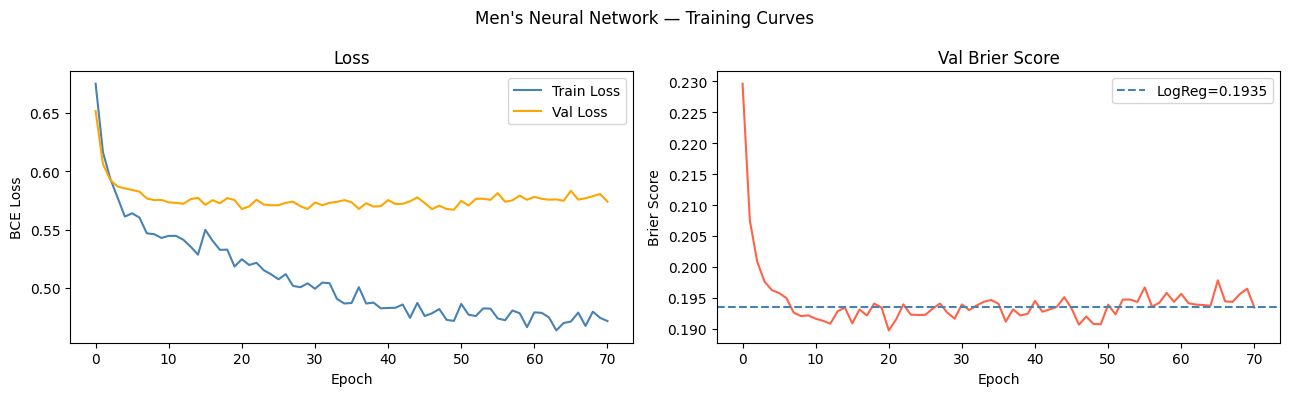

In [11]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Men's Neural Network — Training Curves")

axes[0].plot(m_nn.history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(m_nn.history['val_loss'],   label='Val Loss',   color='orange')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].set_title('Loss')

axes[1].plot(m_nn.history['val_brier'], color='tomato')
axes[1].axhline(m_lr_brier, linestyle='--', color='steelblue', label=f'LogReg={m_lr_brier:.4f}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Brier Score')
axes[1].legend(); axes[1].set_title('Val Brier Score')

plt.tight_layout()
#plt.savefig('../outputs/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

In [12]:
print("=== Women's Neural Network ===")
w_nn = MarchMadnessNet(hidden_dims = [128, 128, 32], dropout = 0.2,
                       lr = 1e-4, weight_decay = 1e-3,
                       batch_size = 64, max_epochs = 200,
                       patience = 50)

w_nn.fit(w_X_train, w_y_train, w_X_val, w_y_val)
w_nn.save(tag='W')

w_nn_preds_val = w_nn.predict_proba(w_X_val)

print("\n--- Women's Model Comparison ---")
w_naive = np.full(len(w_y_val), 0.5)
evaluate(w_y_val, w_naive,        'Naive 0.5')
evaluate(w_y_val, w_lr_preds_val, 'Logistic Regression')
evaluate(w_y_val, w_nn_preds_val, 'Neural Network')

=== Women's Neural Network ===
Using Apple MPS (GPU)
Epoch   1 | train_loss = 0.6977 val_loss = 0.6966  val_brier = 0.2517 (best)
Epoch  20 | train_loss = 0.4949 val_loss = 0.4894  val_brier = 0.1592 (best)
Epoch  40 | train_loss = 0.4519 val_loss = 0.4612  val_brier = 0.1508 (no improve 1)
Epoch  60 | train_loss = 0.4296 val_loss = 0.4528  val_brier = 0.1487 (no improve 1)
Epoch  80 | train_loss = 0.4026 val_loss = 0.4560  val_brier = 0.1507 (no improve 12)
Epoch 100 | train_loss = 0.3815 val_loss = 0.4557  val_brier = 0.1503 (no improve 32)

Early stopping at epoch 118. Best val Brier: 0.1483

Training complete. Best val Brier: 0.1483
Preprocessor saved to /Users/adamgold/Desktop/MM_26/models/W_nn_prep.pkl
Model saved → models/W_nn.pt

--- Women's Model Comparison ---
Naive 0.5                            Brier=0.2500  LogLoss=0.6931
Logistic Regression                  Brier=0.1381  LogLoss=0.4235
Neural Network                       Brier=0.1483  LogLoss=0.4506


(0.14831146807197915, 0.45061249614502075)

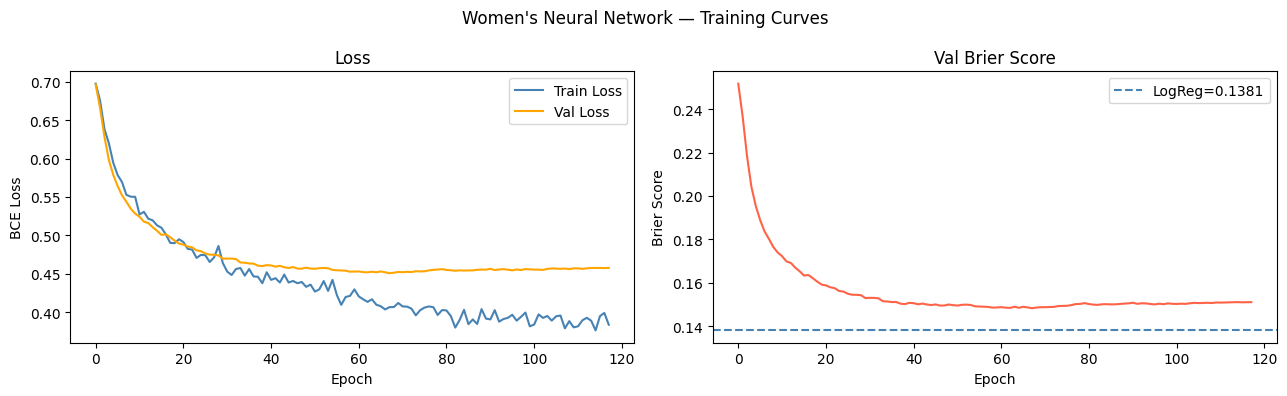

In [13]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Women's Neural Network — Training Curves")

axes[0].plot(w_nn.history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(w_nn.history['val_loss'],   label='Val Loss',   color='orange')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].set_title('Loss')

axes[1].plot(w_nn.history['val_brier'], color='tomato')
axes[1].axhline(w_lr_brier, linestyle='--', color='steelblue', label=f'LogReg={w_lr_brier:.4f}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Brier Score')
axes[1].legend(); axes[1].set_title('Val Brier Score')

plt.tight_layout()
#plt.savefig('../outputs/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Save Best Model Choice

Record which model won on the validation set for use in the prediction notebook.

In [14]:
import json

m_nn_brier  = float(np.mean((m_nn_preds_val - m_y_val) ** 2))
w_nn_brier  = float(np.mean((w_nn_preds_val - w_y_val) ** 2))
w_lr_brier_val = float(np.mean((w_lr_preds_val - w_y_val) ** 2))

results = {
    "M": {
        "best_model":  "nn" if m_nn_brier < m_lr_brier else "logreg",
        "nn_brier":    round(m_nn_brier, 5),
        "logreg_brier": round(m_lr_brier, 5),
        "diff_cols":   m_diff_cols,
    },
    "W": {
        "best_model":  "nn" if w_nn_brier < w_lr_brier_val else "logreg",
        "nn_brier":    round(w_nn_brier, 5),
        "logreg_brier": round(w_lr_brier_val, 5),
        "diff_cols":   w_diff_cols,
    }
}

with open(PROC_DIR / 'model_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Model results saved → data/processed/model_results.json")
print(json.dumps(results, indent=2))

Model results saved → data/processed/model_results.json
{
  "M": {
    "best_model": "nn",
    "nn_brier": 0.18975,
    "logreg_brier": 0.19347,
    "diff_cols": [
      "diff_PointsFor",
      "diff_PointsAgn",
      "diff_WinPct",
      "diff_ASTpg",
      "diff_TOpg",
      "diff_STLpg",
      "diff_BLKpg",
      "diff_FGpct",
      "diff_FG3pct",
      "diff_PointDiff",
      "diff_eFG_pct",
      "diff_TOV_pct",
      "diff_ORB_pct",
      "diff_FTR",
      "diff_Def_eFG_pct",
      "diff_rank_MAS",
      "diff_rank_MOR",
      "diff_rank_POM",
      "diff_SeedNum"
    ]
  },
  "W": {
    "best_model": "logreg",
    "nn_brier": 0.14831,
    "logreg_brier": 0.13811,
    "diff_cols": [
      "diff_PointsFor",
      "diff_PointsAgn",
      "diff_WinPct",
      "diff_ASTpg",
      "diff_TOpg",
      "diff_STLpg",
      "diff_BLKpg",
      "diff_FGpct",
      "diff_FG3pct",
      "diff_PointDiff",
      "diff_eFG_pct",
      "diff_TOV_pct",
      "diff_ORB_pct",
      "diff_FTR",
     

## Summary

| Model | Val Brier (Men) | Val Brier (Women) |
|---|---|---|
| Naive 0.5 | 0.2500 | 0.2500 |
| Logistic Regression | | |
| Neural Network | | |

**Next:** `04_predict.ipynb` — run the best model on 2026 matchups and generate `submission.csv`